# Module 6 Homework: Tree-Based Methods and the Classifier Comparison
#### **Breck, Fangyi, Luis**  
Apr 13, 2026

# Problem 1: Splitting Criterion (Pen & Paper)
 
Consider a binary classification problem. A node contains $N$ samples, of which $N_1$ belong to class 1. Define $p = N_1 / N$.
 
---
 
## Part (a): Gini Impurity and Shannon Entropy
 
**Write down the Gini impurity $G(p)$ and the Shannon entropy $H(p)$ for binary classification. Show that both are maximized at $p = 1/2$ and equal zero at $p = 0$ and $p = 1$.**
 
### Definitions
 
The **Gini impurity** for binary classification is:
 
$$G(p) = 2p(1 - p)$$
 
The **Shannon entropy** for binary classification is:
 
$$H(p) = -p \log_2 p - (1 - p) \log_2(1 - p)$$
 
### Showing both equal zero at $p = 0$ and $p = 1$
 
**Gini impurity:**
 
$$G(0) = 2 \cdot 0 \cdot (1 - 0) = 2 \cdot 0 \cdot 1 = 0$$
 
$$G(1) = 2 \cdot 1 \cdot (1 - 1) = 2 \cdot 1 \cdot 0 = 0$$
 
**Shannon entropy** (using the convention $0 \log_2 0 = 0$):
 
$$H(0) = -0 \cdot \log_2 0 - 1 \cdot \log_2 1 = 0 - 0 = 0$$
 
$$H(1) = -1 \cdot \log_2 1 - 0 \cdot \log_2 0 = 0 - 0 = 0$$
 
### Showing both are maximized at $p = 1/2$
 
**Gini impurity — take the first derivative and set it to zero:**
 
$$G(p) = 2p(1 - p) = 2p - 2p^2$$
 
$$\frac{dG}{dp} = 2 - 4p$$
 
Set $\frac{dG}{dp} = 0$:
 
$$2 - 4p = 0 \implies p = \frac{1}{2}$$
 
Check second derivative to confirm it is a maximum:
 
$$\frac{d^2G}{dp^2} = -4 < 0 \quad \text{(concave down, so } p = 1/2 \text{ is a maximum)}$$
 
The maximum value is:
 
$$G\!\left(\frac{1}{2}\right) = 2 \cdot \frac{1}{2} \cdot \frac{1}{2} = \frac{1}{2}$$
 
**Shannon entropy — take the first derivative and set it to zero:**
 
$$H(p) = -p \log_2 p - (1 - p)\log_2(1 - p)$$
 
Using $\frac{d}{dp}[p \log_2 p] = \log_2 p + \frac{1}{\ln 2}$ and $\frac{d}{dp}[(1-p)\log_2(1-p)] = -\log_2(1-p) - \frac{1}{\ln 2}$:
 
$$\frac{dH}{dp} = -\log_2 p - \frac{1}{\ln 2} + \log_2(1 - p) + \frac{1}{\ln 2}$$
 
$$\frac{dH}{dp} = -\log_2 p + \log_2(1 - p)$$
 
$$\frac{dH}{dp} = \log_2\!\left(\frac{1 - p}{p}\right)$$
 
Set $\frac{dH}{dp} = 0$:
 
$$\log_2\!\left(\frac{1 - p}{p}\right) = 0 \implies \frac{1 - p}{p} = 2^0 = 1 \implies 1 - p = p \implies p = \frac{1}{2}$$
 
Check second derivative to confirm maximum:
 
$$\frac{d^2H}{dp^2} = \frac{-1}{p \ln 2} - \frac{1}{(1-p)\ln 2} = \frac{-1}{\ln 2}\left(\frac{1}{p} + \frac{1}{1-p}\right) < 0 \quad \forall\; p \in (0,1)$$
 
This is strictly negative, confirming concavity and that $p = 1/2$ is a maximum.
 
The maximum value is:
 
$$H\!\left(\frac{1}{2}\right) = -\frac{1}{2}\log_2\frac{1}{2} - \frac{1}{2}\log_2\frac{1}{2} = -\frac{1}{2}(-1) - \frac{1}{2}(-1) = 1$$
 
---
 
## Part (b): Weighted Impurity and Concavity
 
**A split divides the node into a left child ($N_L$ samples, class-1 fraction $p_L$) and a right child ($N_R$ samples, class-1 fraction $p_R$). The weighted impurity after the split is:**
 
$$G_{\text{split}} = \frac{N_L}{N}\,G(p_L) + \frac{N_R}{N}\,G(p_R)$$
 
**Using the concavity of $G(p)$, show that $G_{\text{split}} \le G(p)$ for any split. What does this guarantee about the tree-growing algorithm?**
 
### Proof using Jensen's Inequality
 
Since $G(p)$ is a **concave** function (we showed $G''(p) = -4 < 0$), Jensen's inequality states that for any concave function $f$, weights $w_i \ge 0$ with $\sum w_i = 1$, and points $x_i$:
 
$$f\!\left(\sum_i w_i \, x_i\right) \ge \sum_i w_i \, f(x_i)$$
 
Define the weights as:
 
$$w_L = \frac{N_L}{N}, \quad w_R = \frac{N_R}{N}$$
 
Note that $w_L + w_R = \frac{N_L + N_R}{N} = \frac{N}{N} = 1$.
 
Now, the overall class-1 fraction at the parent node is a weighted average of the children's fractions:
 
$$p = \frac{N_1}{N} = \frac{N_L \cdot p_L + N_R \cdot p_R}{N} = w_L \, p_L + w_R \, p_R$$
 
Apply Jensen's inequality with $f = G$:
 
$$G(p) = G(w_L \, p_L + w_R \, p_R) \ge w_L \, G(p_L) + w_R \, G(p_R) = G_{\text{split}}$$
 
Therefore:
 
$$\boxed{G_{\text{split}} \le G(p)}$$
 
### What this guarantees
 
This guarantees that **every split can only decrease (or maintain) the impurity** — it can never increase it. Therefore, the greedy tree-growing algorithm, which picks the split that minimizes $G_{\text{split}}$, is guaranteed to **monotonically reduce impurity** at every step. Each split makes the child nodes at least as pure as (and typically purer than) the parent node.
 
---
 
## Part (c): Computing $G_{\text{split}}$ for Two Candidate Splits
 
**A node contains 20 samples: 12 from class 0 and 8 from class 1. Two candidate splits are proposed:**
 
| | Left child | Right child |
|---|---|---|
| Split A | 10 class-0, 2 class-1 | 2 class-0, 6 class-1 |
| Split B | 6 class-0, 6 class-1 | 6 class-0, 2 class-1 |
 
**Compute $G_{\text{split}}$ for both splits.**
 
### Parent node (for reference)
 
$$N = 20, \quad N_1 = 8, \quad p = \frac{8}{20} = 0.4$$
 
$$G(p) = 2 \cdot 0.4 \cdot 0.6 = 0.48$$
 
### Split A
 
**Left child:** $N_L = 10 + 2 = 12$, class-1 count $= 2$, so $p_L = \frac{2}{12} = \frac{1}{6}$
 
$$G(p_L) = 2 \cdot \frac{1}{6} \cdot \left(1 - \frac{1}{6}\right) = 2 \cdot \frac{1}{6} \cdot \frac{5}{6} = \frac{10}{36} = \frac{5}{18}$$
 
**Right child:** $N_R = 2 + 6 = 8$, class-1 count $= 6$, so $p_R = \frac{6}{8} = \frac{3}{4}$
 
$$G(p_R) = 2 \cdot \frac{3}{4} \cdot \left(1 - \frac{3}{4}\right) = 2 \cdot \frac{3}{4} \cdot \frac{1}{4} = \frac{6}{16} = \frac{3}{8}$$
 
**Weighted impurity:**
 
$$G_{\text{split}}^{A} = \frac{12}{20} \cdot \frac{5}{18} + \frac{8}{20} \cdot \frac{3}{8}$$

 
$$= \frac{19}{60} \approx 0.3167$$
 
### Split B
 
**Left child:** $N_L = 6 + 6 = 12$, class-1 count $= 6$, so $p_L = \frac{6}{12} = \frac{1}{2}$
 
$$G(p_L) = 2 \cdot \frac{1}{2} \cdot \frac{1}{2} = \frac{1}{2}$$
 
**Right child:** $N_R = 6 + 2 = 8$, class-1 count $= 2$, so $p_R = \frac{2}{8} = \frac{1}{4}$
 
$$G(p_R) = 2 \cdot \frac{1}{4} \cdot \frac{3}{4} = \frac{6}{16} = \frac{3}{8}$$
 
**Weighted impurity:**
 
$$G_{\text{split}}^{B} = \frac{12}{20} \cdot \frac{1}{2} + \frac{8}{20} \cdot \frac{3}{8}$$
 
$$= \frac{9}{20} = 0.45$$
 
### Comparison
 
| Split | $G_{\text{split}}$ | Decimal |
|---|---|---|
| A | $19/60$ | $\approx 0.3167$ |
| B | $9/20$ | $= 0.45$ |
| Parent | — | $0.48$ |
 
**The tree algorithm prefers Split A** because it has the lower weighted Gini impurity ($0.3167 < 0.45$), meaning it produces child nodes that are more pure — Split A separates the two classes much more effectively than Split B, whose left child is a 50/50 mix.
 
---

## **Problem 2**

Training set size: 210
Test set size:     90

Part (a): Bootstrap Sampling
  Bootstrap sample 1: unique fraction = 0.6571 (65.7%)
  Bootstrap sample 2: unique fraction = 0.6238 (62.4%)
  Bootstrap sample 3: unique fraction = 0.6048 (60.5%)
  Bootstrap sample 4: unique fraction = 0.6048 (60.5%)
  Bootstrap sample 5: unique fraction = 0.6381 (63.8%)

  Theoretical value (1 - 1/e): 0.6321 (63.2%)
  All fractions should be close to this value.

Part (b): Train Individual Trees
  Tree 1: test accuracy = 0.7778 (77.8%)
  Tree 2: test accuracy = 0.7444 (74.4%)
  Tree 3: test accuracy = 0.8222 (82.2%)
  Tree 4: test accuracy = 0.8778 (87.8%)
  Tree 5: test accuracy = 0.8889 (88.9%)

Part (c): Majority Vote Ensemble
  Ensemble (majority vote) accuracy: 0.8333 (83.3%)
  Average individual tree accuracy:  0.8222 (82.2%)
  Best individual tree accuracy:     0.8889 (88.9%)

  ✓ Ensemble is BETTER than the average individual tree.
  ✗ Ensemble is NOT better than the best individual tree.

Part (d): 

/var/folders/2k/q7xz3f9s0tvb_rts8x0s9g1r0000gn/T/ipykernel_93051/2791825412.py:197: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  ensemble_predictions, _ = mode(all_predictions, axis=0)
/var/folders/2k/q7xz3f9s0tvb_rts8x0s9g1r0000gn/T/ipykernel_93051/2791825412.py:283: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `

  B = 200:  Manual RF = 0.8667  |  sklearn RF = 0.8778



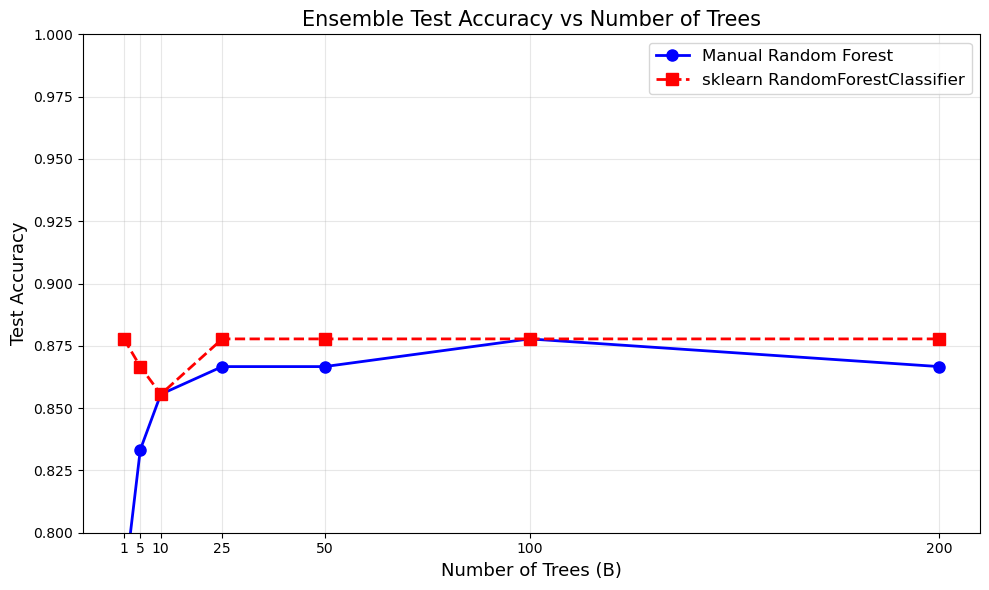

  Plot saved as 'ensemble_accuracy_vs_B.png'

Part (e): Discussion

  (i) Which term is reduced by increasing B?
  
      The second term, (1 - rho)/B · sigma², is reduced by increasing B.
      As B → infinity, this term → 0. This is the "averaging effect":
      aggregating more independent-ish models reduces the variance
      contribution from individual model noise.
      
  (ii) What is the role of max_features='sqrt' in reducing the other term?
  
      The first term, rho(sigma)², depends on the pairwise correlation rho between
      trees. If all trees see all features, they tend to make similar splits
      (especially on strong features), leading to high correlation rho.
      
      By setting max_features='sqrt', each tree only considers a random
      subset of features at each split. This DECORRELATES the trees,
      reducing rho, which in turn reduces the rho(sigma)² term.
      
      In essence: max_features='sqrt' ensures the trees are diverse,
      which is critic

In [ ]:
# =============================================================================
# Problem 2: Building a Random Forest from Scratch
# =============================================================================


# ---- Import all required libraries ----
import numpy as np                          
import matplotlib.pyplot as plt             
from sklearn.datasets import make_moons     
from sklearn.model_selection import train_test_split  
from sklearn.tree import DecisionTreeClassifier       
from sklearn.ensemble import RandomForestClassifier   
from scipy.stats import mode                          

# =============================================================================
# Step 0: Generate the dataset and split into train/test
# =============================================================================

# Generate 300 samples from the two moons dataset.
# noise=0.3 adds Gaussian noise to make the classification harder.
# random_state=42 ensures reproducibility of the data generation.
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Split into 70% training and 30% testing.
# random_state=0 ensures reproducibility of the split.
# This gives us 210 training samples and 90 test samples.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                    # Features and labels
    test_size=0.3,           # 30% of data goes to the test set
    random_state=0           # Seed for reproducibility
)

# Print the sizes to confirm the split
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print()

# =============================================================================
# Part (a): Bootstrap Sampling
# =============================================================================
# A bootstrap sample draws N samples WITH REPLACEMENT from a dataset of size N.
# Because we sample with replacement, some points will appear multiple times
# and some will not appear at all. Theory predicts that the fraction of unique
# points in a bootstrap sample converges to 1 - 1/e ≈ 63.2%.
#
# Why? The probability that a specific point is NOT chosen in one draw is
# (N-1)/N. Over N draws, the probability it's never chosen is ((N-1)/N)^N,
# which converges to 1/e as N -> infinity. So the probability it IS chosen
# at least once is 1 - 1/e ≈ 0.632.
# =============================================================================

def bootstrap_sample(X, y, random_state=None):
    """
    Draw a bootstrap sample of size N from a dataset of size N.
    
    Parameters
    ----------
    X : np.ndarray of shape (N, d)
        Feature matrix with N samples and d features.
    y : np.ndarray of shape (N,)
        Label vector with N samples.
    random_state : int or None
        Seed for the random number generator for reproducibility.
        If None, results will vary between calls.
    
    Returns
    -------
    X_boot : np.ndarray of shape (N, d)
        The bootstrapped feature matrix (may contain duplicate rows).
    y_boot : np.ndarray of shape (N,)
        The corresponding bootstrapped labels.
    unique_fraction : float
        The fraction of unique original indices that appear in the sample.
    """
    # Create a random number generator with the given seed
    rng = np.random.RandomState(random_state)
    
    # Get the number of samples in the dataset
    N = X.shape[0]
    
    # Draw N random indices from [0, N) WITH REPLACEMENT.
    # Some indices will be repeated; others will be missing entirely.
    indices = rng.randint(0, N, size=N)
    
    # Use the sampled indices to select rows from X and y
    X_boot = X[indices]   # Shape: (N, d) — same size as original
    y_boot = y[indices]   # Shape: (N,)   — same size as original
    
    # Compute the fraction of unique training points included.
    # np.unique returns only the distinct values in the array.
    n_unique = len(np.unique(indices))
    unique_fraction = n_unique / N
    
    return X_boot, y_boot, unique_fraction


# Generate 5 bootstrap samples and report the unique fraction for each
print("=" * 60)
print("Part (a): Bootstrap Sampling")
print("=" * 60)

# Store bootstrap samples for use in later parts
bootstrap_samples = []

for i in range(5):
    # Use different random seeds (0 through 4) for each bootstrap sample
    X_boot, y_boot, unique_frac = bootstrap_sample(X_train, y_train, random_state=i)
    
    # Save this bootstrap sample for training trees later
    bootstrap_samples.append((X_boot, y_boot))
    
    # Print the unique fraction for this sample
    print(f"  Bootstrap sample {i+1}: unique fraction = {unique_frac:.4f} "
          f"({unique_frac*100:.1f}%)")

# Print the theoretical value for comparison
theoretical = 1 - 1 / np.e   # 1 - 1/e ≈ 0.6321
print(f"\n  Theoretical value (1 - 1/e): {theoretical:.4f} ({theoretical*100:.1f}%)")
print(f"  All fractions should be close to this value.")
print()

# =============================================================================
# Part (b): Train Individual Decision Trees
# =============================================================================
# We train one DecisionTreeClassifier on each of the 5 bootstrap samples.
# Key hyperparameters:
#   - max_depth=None: The tree can grow as deep as needed (no pruning).
#     This means each tree will overfit to its bootstrap sample, which is
#     intentional — the ensemble (random forest) will reduce variance.
#   - max_features='sqrt': At each split, only consider sqrt(d) randomly
#     chosen features. This decorrelates the trees, which is critical for
#     the variance reduction property of random forests.
# =============================================================================

print("=" * 60)
print("Part (b): Train Individual Trees")
print("=" * 60)

# List to store the 5 trained decision tree models
trees = []

for i in range(5):
    # Retrieve the i-th bootstrap sample created in Part (a)
    X_boot, y_boot = bootstrap_samples[i]
    
    # Create a decision tree classifier with:
    #   - max_depth=None: no limit on tree depth (fully grown tree)
    #   - max_features='sqrt': at each split, consider sqrt(num_features) features
    #   - random_state=i: for reproducibility of the random feature selection
    tree = DecisionTreeClassifier(
        max_depth=None,          # Grow the tree fully — no depth restriction
        max_features='sqrt',     # Randomly select sqrt(d) features per split
        random_state=i           # Seed for reproducibility
    )
    
    # Fit (train) the tree on the bootstrap sample
    tree.fit(X_boot, y_boot)
    
    # Evaluate the tree's accuracy on the HELD-OUT test set
    # (Note: the tree was trained on a bootstrap sample, not the full training set)
    test_accuracy = tree.score(X_test, y_test)
    
    # Store the trained tree for use in ensemble voting
    trees.append(tree)
    
    # Report the test accuracy of this individual tree
    print(f"  Tree {i+1}: test accuracy = {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")

print()

# =============================================================================
# Part (c): Majority Vote (Ensemble Prediction)
# =============================================================================
# For each test sample, we collect the predictions from all 5 trees and
# take the majority vote (i.e., the most common prediction wins).
# This is the fundamental idea behind bagging / random forests:
# individual trees may overfit differently, but their errors tend to
# cancel out when we average (vote) across many trees.
# =============================================================================

print("=" * 60)
print("Part (c): Majority Vote Ensemble")
print("=" * 60)

# Collect predictions from all 5 trees into a 2D array.
# Shape will be (5, n_test) — one row per tree, one column per test sample.
all_predictions = np.array([
    tree.predict(X_test)    # Each tree predicts all test samples
    for tree in trees       # Loop over all 5 trained trees
])

# Take the majority vote across the 5 trees for each test sample.
# mode() returns the most frequent value along axis=0 (across trees).
# axis=0 means we vote across the 5 trees for each test point.
ensemble_predictions, _ = mode(all_predictions, axis=0)

# mode() returns a 2D array; squeeze to 1D for comparison with y_test
ensemble_predictions = ensemble_predictions.flatten()

# Compute ensemble accuracy: fraction of test samples correctly classified
ensemble_accuracy = np.mean(ensemble_predictions == y_test)

# Compute average and best individual tree accuracy for comparison
individual_accuracies = [tree.score(X_test, y_test) for tree in trees]
avg_individual = np.mean(individual_accuracies)
best_individual = np.max(individual_accuracies)

print(f"  Ensemble (majority vote) accuracy: {ensemble_accuracy:.4f} "
      f"({ensemble_accuracy*100:.1f}%)")
print(f"  Average individual tree accuracy:  {avg_individual:.4f} "
      f"({avg_individual*100:.1f}%)")
print(f"  Best individual tree accuracy:     {best_individual:.4f} "
      f"({best_individual*100:.1f}%)")
print()

# Check: is ensemble better than average individual tree?
if ensemble_accuracy > avg_individual:
    print("  ✓ Ensemble is BETTER than the average individual tree.")
else:
    print("  ✗ Ensemble is NOT better than the average individual tree.")

# Check: is ensemble better than the best individual tree?
if ensemble_accuracy > best_individual:
    print("  ✓ Ensemble is BETTER than the best individual tree.")
elif ensemble_accuracy == best_individual:
    print("  ≈ Ensemble TIES with the best individual tree.")
else:
    print("  ✗ Ensemble is NOT better than the best individual tree.")

print()

# =============================================================================
# Part (d): Scaling Up — Varying the Number of Trees B
# =============================================================================
# We repeat the full bootstrap + train + majority-vote pipeline for
# B = 1, 5, 10, 25, 50, 100, 200 trees.
# We also compare against sklearn's RandomForestClassifier with the same B.
#
# As B increases, we expect the ensemble accuracy to improve and then plateau.
# =============================================================================

print("=" * 60)
print("Part (d): Scaling Up — Ensemble Accuracy vs B")
print("=" * 60)

# Define the list of ensemble sizes to test
B_values = [1, 5, 10, 25, 50, 100, 200]

# Lists to store results for plotting
manual_accuracies = []     # Our hand-built random forest accuracies
sklearn_accuracies = []    # sklearn RandomForestClassifier accuracies

for B in B_values:
    # ----- Manual Random Forest -----
    
    # Step 1: Generate B bootstrap samples and train B trees
    manual_trees = []
    for b in range(B):
        # Create bootstrap sample with a unique seed for each tree
        X_boot, y_boot, _ = bootstrap_sample(X_train, y_train, random_state=b)
        
        # Train a decision tree on this bootstrap sample
        tree = DecisionTreeClassifier(
            max_depth=None,          # Fully grown tree
            max_features='sqrt',     # Random feature subset at each split
            random_state=b           # Reproducible
        )
        tree.fit(X_boot, y_boot)
        manual_trees.append(tree)
    
    # Step 2: Collect predictions from all B trees
    # Shape: (B, n_test)
    all_preds = np.array([t.predict(X_test) for t in manual_trees])
    
    # Step 3: Majority vote across all B trees
    if B == 1:
        # With only 1 tree, the "majority vote" is just that tree's prediction
        ensemble_preds = all_preds[0]
    else:
        # Take the mode (most common prediction) across all trees
        ensemble_preds, _ = mode(all_preds, axis=0)
        ensemble_preds = ensemble_preds.flatten()
    
    # Compute accuracy of our manual ensemble
    manual_acc = np.mean(ensemble_preds == y_test)
    manual_accuracies.append(manual_acc)
    
    # ----- sklearn RandomForestClassifier -----
    
    # Train sklearn's random forest with the same number of estimators
    # and hyperparameters for a fair comparison
    rf = RandomForestClassifier(
        n_estimators=B,          # Number of trees in the forest
        max_depth=None,          # Fully grown trees
        max_features='sqrt',     # Same feature subsampling as our manual version
        random_state=42          # Reproducible
    )
    rf.fit(X_train, y_train)
    
    # Compute accuracy of sklearn's random forest
    sklearn_acc = rf.score(X_test, y_test)
    sklearn_accuracies.append(sklearn_acc)
    
    # Print comparison for this value of B
    print(f"  B = {B:>3d}:  Manual RF = {manual_acc:.4f}  |  "
          f"sklearn RF = {sklearn_acc:.4f}")

print()

# ----- Create the comparison plot -----

plt.figure(figsize=(10, 6))

# Plot our manual random forest accuracy
plt.plot(
    B_values,                    # x-axis: number of trees
    manual_accuracies,           # y-axis: test accuracy
    'bo-',                       # Blue circles connected by solid lines
    label='Manual Random Forest',# Legend label
    linewidth=2,                 # Thicker line for visibility
    markersize=8                 # Larger markers
)

# Plot sklearn's RandomForestClassifier accuracy
plt.plot(
    B_values,                    # x-axis: number of trees
    sklearn_accuracies,          # y-axis: test accuracy
    'rs--',                      # Red squares connected by dashed lines
    label='sklearn RandomForestClassifier',  # Legend label
    linewidth=2,                 # Thicker line for visibility
    markersize=8                 # Larger markers
)

# Add labels, title, legend, and grid
plt.xlabel('Number of Trees (B)', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.title('Ensemble Test Accuracy vs Number of Trees', fontsize=15)
plt.legend(fontsize=12)                       # Show the legend
plt.grid(True, alpha=0.3)                     # Light grid for readability
plt.xticks(B_values)                          # Show all B values on x-axis
plt.ylim(0.80, 1.0)                           # Set y-axis range for clarity
plt.tight_layout()                            # Prevent label clipping

# Save the figure as a PNG file
plt.savefig('ensemble_accuracy_vs_B.png', dpi=150)
plt.show()

print("  Plot saved as 'ensemble_accuracy_vs_B.png'")
print()

# =============================================================================
# Part (e): Discussion
# =============================================================================
# The variance of an ensemble of B models with pairwise correlation ρ
# and individual variance σ² is:
#
#     Var(f̄) = ρσ² + (1 - ρ)/B · σ²
#
# We now answer three conceptual questions using our experimental results.
# =============================================================================

print("=" * 60)
print("Part (e): Discussion")
print("=" * 60)

print("""
  (i) Which term is reduced by increasing B?
  
      The second term, (1 - rho)/B · sigma², is reduced by increasing B.
      As B → infinity, this term → 0. This is the "averaging effect":
      aggregating more independent-ish models reduces the variance
      contribution from individual model noise.
      
  (ii) What is the role of max_features='sqrt' in reducing the other term?
  
      The first term, rho(sigma)², depends on the pairwise correlation rho between
      trees. If all trees see all features, they tend to make similar splits
      (especially on strong features), leading to high correlation rho.
      
      By setting max_features='sqrt', each tree only considers a random
      subset of features at each split. This DECORRELATES the trees,
      reducing rho, which in turn reduces the rho(sigma)² term.
      
      In essence: max_features='sqrt' ensures the trees are diverse,
      which is critical for the ensemble to be effective.
      
  (iii) Why does the ensemble accuracy plateau rather than continuing
        to improve indefinitely?
        
      As B → infinity, the second term (1-rho)/B · sigma² → 0, but the first
      term rho(sigma)² remains. This is an irreducible floor: no matter how
      many trees we add, the ensemble variance cannot go below rho(sigma)².
      
      This floor exists because the trees are not perfectly independent
      (rho > 0). They all train on the same underlying data distribution
      and share structural similarities. The plateau in accuracy reflects
      reaching this irreducible variance floor.
""")

---

## **Problem 3**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)
print(f'Train: {len(y_train)}, Test: {len(y_test)}')

Train: 210, Test: 90


### **(a)**

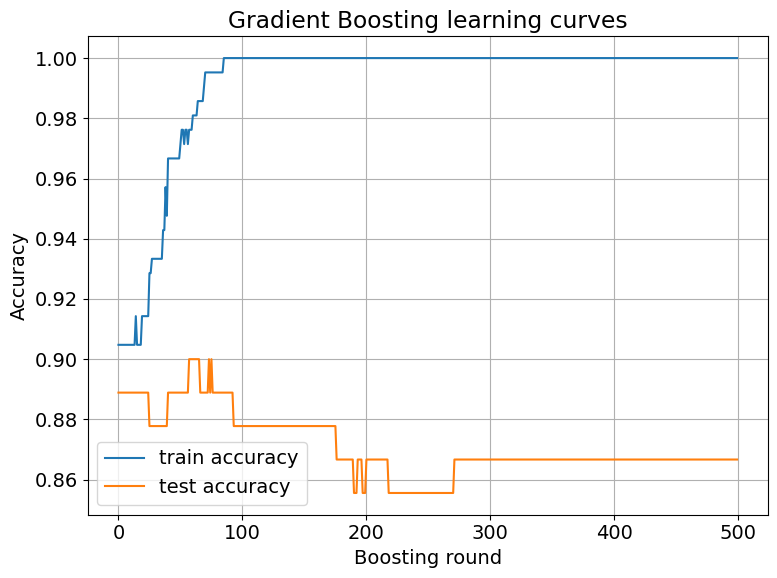

Best test accuracy: 0.90
Best round: 58


In [ ]:
gb = GradientBoostingClassifier(n_estimators=500, max_depth=3, learning_rate=0.1, random_state=0)
gb.fit(X_train, y_train)
gb_test_accs = []
gb_train_accs = []

for y_train_pred, y_test_pred in zip(gb.staged_predict(X_train), gb.staged_predict(X_test)):
    gb_train_accs.append(accuracy_score(y_train, y_train_pred))
    gb_test_accs.append(accuracy_score(y_test, y_test_pred))


plt.figure()
plt.plot(gb_train_accs, label="train accuracy")
plt.plot(gb_test_accs, label="test accuracy")
plt.xlabel("Boosting round")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting learning curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

best_round = np.argmax(gb_test_accs) + 1
best_test_acc = np.max(gb_test_accs)

print(f'Best test accuracy: {best_test_acc:.2f}')
print(f'Best round: {best_round}')

The test accuracy increases at small boosting round and eventually decrease. The turning point is at approximately 58 with a best test accuracy of 0.90.

### **(b)**

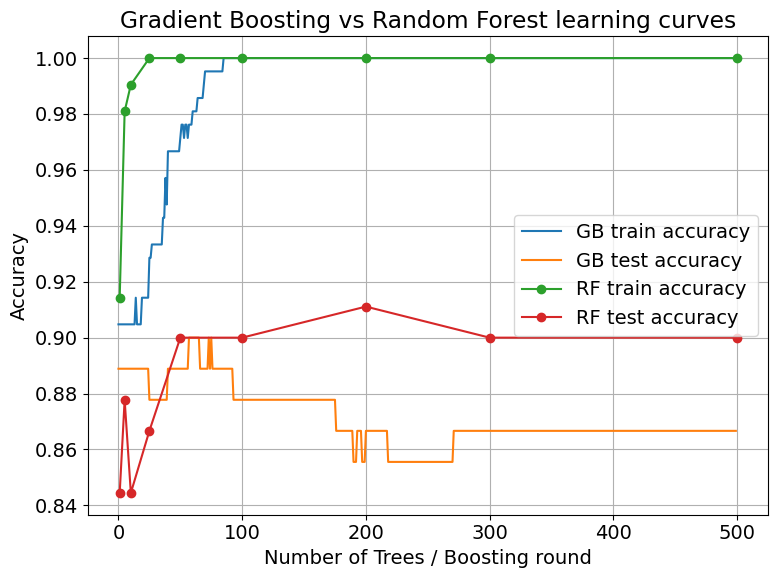

In [ ]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300, 500]

rf_test_accs = []
rf_train_accs = []
for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=None, max_features='sqrt', random_state=0)
    rf.fit(X_train, y_train)
    rf_train_accs.append(accuracy_score(y_train, rf.predict(X_train)))
    rf_test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure()
plt.plot(gb_train_accs, label="GB train accuracy")
plt.plot(gb_test_accs, label="GB test accuracy")
plt.plot(n_trees_list, rf_train_accs, "o-", label="RF train accuracy")
plt.plot(n_trees_list, rf_test_accs, "o-", label="RF test accuracy")
plt.xlabel("Number of Trees / Boosting round")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting vs Random Forest learning curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The random forest curve, though fluctuating, does not have an obvious decreasing trend. Gradient boosting adds trees to correct previous errors, so later trees can start fitting noise in the training set, which can reduce the test accuracy. In contrast, random forest trains trees independently. So adding trees simply reduce the variance and does not make the test accuracy decrease.

### **(c)**

Gradient boosting is analogous to neural network in the sense that each new tree is added in the direction that reduces the current loss, just as each neural network parameter update moves along the negative gradient of the loss. The "learning rate" is given by a shrinkage factor multiplying the tree in gradient boosting, and in neural network is the step size used in parameter updates. The boosting round plays the role of the "number of steps". In both methods, taking too many steps or using too large a rate can overfit the training data and start fitting noise. So test accuracy can eventually decrease in both.

---

## **Problem 4: Classifier Shootout**

You will now apply every classifier from Modules 4–6 to the Ising model phase classification problem from Module 5. This is the same dataset used in the neural network lectures — each sample is a $10 \times 10$ spin configuration, and the label is ordered ($0$) versus disordered ($1$).

- Generate the data using the `generate_ising_dataset` function from lecture (or load the saved `.npz` file).  
- Use $400$ samples per phase.  
- Split the dataset into training and testing sets using a $70/30$ split with `random_state = 0`.

---

### A. Train All Classifiers

Fit each of the following classifiers to the Ising training data:

1. Logistic regression (`LogisticRegression`, `max_iter = 1000`)  
2. k-Nearest Neighbors (`KNeighborsClassifier`, $k = 5$)  
3. Decision tree (`DecisionTreeClassifier`, `max_depth = 5`)  
4. Random forest (`RandomForestClassifier`, $200$ trees)  
5. Gradient boosting (`GradientBoostingClassifier`, $200$ trees, `max_depth = 3`, learning rate $= 0.1$)  
6. Neural network (use your PyTorch FlexNet from Module 5, hidden layers $[64, 32]$, ReLU activation, $150$ epochs)

For Each Classifier, Report:

- Test accuracy  
- AUC (area under the ROC curve)  
- Training time (use `time.time()`)

---

In [ ]:
### IMPORTS

import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [ ]:
### FUNCTIONS FROM LECTURE

def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    """Metropolis Monte Carlo for 2D Ising model."""
    if rng is None:
        rng = np.random.default_rng()
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins


def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=10000, rng=None):
    """Generate labeled Ising configurations: ordered (0) vs disordered (1)."""
    if rng is None:
        rng = np.random.default_rng()
    T_c = 2.269
    T_low = rng.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = rng.uniform(2.8, 4.0, size=n_samples_per_phase)
    
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    
    X = np.array(configs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    T_arr = np.array(temps)
    idx = rng.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]

In [ ]:
# generate data (takes a while)
X, y, T = generate_ising_dataset(L=10, n_samples_per_phase=400)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [ ]:
### HELPER FUNCTION
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    start = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "AUC": auc,
        "Train Time (s)": train_time
    })

In [ ]:
### FLEXNET
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


In [ ]:
### TRAIN MODELS
results = []

# logistic regression
log_reg = LogisticRegression(max_iter=1000)
evaluate_model(log_reg, X_train, X_test, y_train, y_test, "Logistic Regression")

# knn (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, "k-NN (k=5)")

# decision tree
tree = DecisionTreeClassifier(max_depth=5)
evaluate_model(tree, X_train, X_test, y_train, y_test, "Decision Tree")

# random forest
rf = RandomForestClassifier(n_estimators=200)
evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")

# gradient boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1
)
evaluate_model(gb, X_train, X_test, y_train, y_test, "Gradient Boosting")

# pytorch flex net
nn_model = FlexNet(
    input_dim=100,
    hidden_sizes=[64, 32],
    activation='relu'
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3)

start = time.time()

for epoch in range(150):
    optimizer.zero_grad()
    
    outputs = nn_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()

train_time = time.time() - start

with torch.no_grad():
    probs = nn_model(X_test_t).numpy()
    preds = (probs > 0.5).astype(int)

acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

results.append({
    "Model": "Neural Network (FlexNet)",
    "Accuracy": acc,
    "AUC": auc,
    "Train Time (s)": train_time
})

In [ ]:
### CREATE TABLE
import pandas as pd

df = pd.DataFrame(results)
df = df.round({
    "Accuracy": 3,
    "AUC": 3,
    "Train Time (s)": 3
})

# sort by accuracy
df = df.sort_values(by="Accuracy", ascending=False)

df

,Model,Accuracy,AUC,Train Time (s)
3,Random Forest,0.996,1.000,0.252
4,Gradient Boosting,0.992,1.000,0.365
5,Neural Network (FlexNet),0.988,1.000,0.165
2,Decision Tree,0.942,0.933,0.010
1,k-NN (k=5),0.871,0.930,0.001
0,Logistic Regression,0.704,0.560,0.016


## B. ROC Curves
Plot the ROC curve for all six classifiers on a single set of axes, with AUC
values in the legend.

---

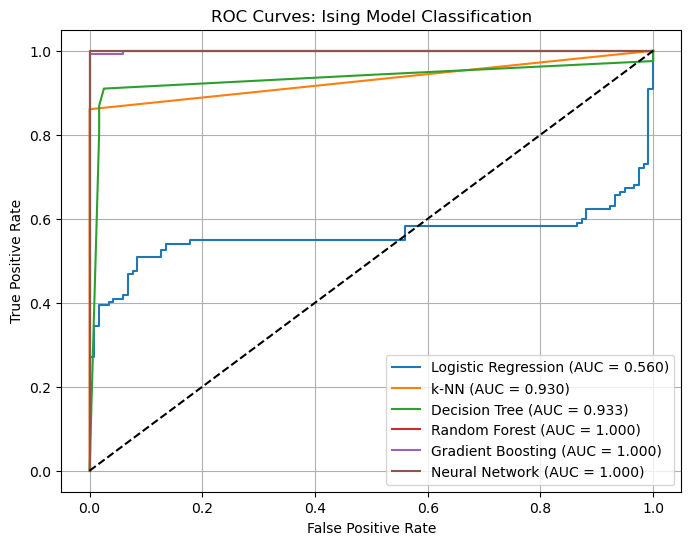

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

roc_data = {}

models = {
    "Logistic Regression": log_reg,
    "k-NN": knn,
    "Decision Tree": tree,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr, sk_auc(fpr, tpr))


with torch.no_grad():
    y_score = nn_model(X_test_t).numpy()

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_data["Neural Network"] = (fpr, tpr, sk_auc(fpr, tpr))

plt.figure(figsize=(8, 6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ising Model Classification")
plt.legend()
plt.grid(True)

plt.show()

## C. Engineered features

Add three hand-crafted features to the raw spin data:

- Signed magnetization:
  $$
  M = \frac{1}{N}\sum_i s_i
  $$

- Absolute magnetization:
  $$
  |M|
  $$

- Nearest-neighbor energy:
  $$
  E = -\frac{1}{N_{\text{bonds}}} \sum_{\langle i,j\rangle} s_i s_j
  $$

### Tasks

1. Retrain **logistic regression** and **gradient boosting** on the augmented feature set (103 features).

2. Report the new accuracies and compare to part (a).

3. For gradient boosting:
   - Plot the top-15 feature importance bar chart.
   - Determine whether $|M|$ dominates.

What does this tell you about what the tree-based method “discovered” from the raw spins?

---

Logistic Regression (engineered):
Accuracy: 0.9917
AUC: 0.999

Gradient Boosting (engineered):
Accuracy: 0.9958
AUC: 0.9959


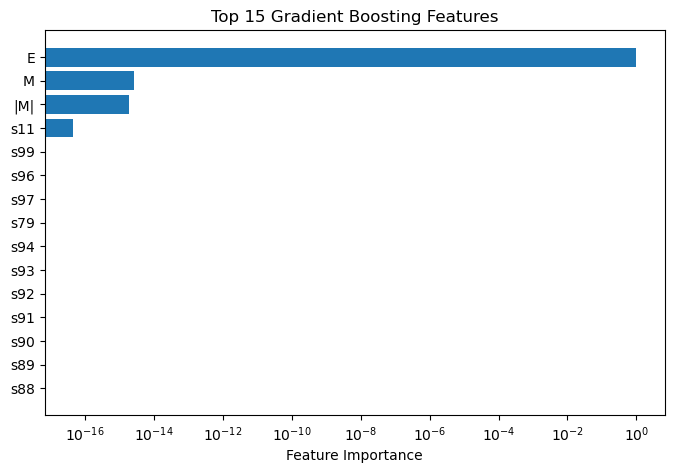

In [ ]:
L = 10
N = L * L

# feature engineering
def engineer_features(X):
    features = []

    for x in X:
        spins = x.reshape(L, L)

        # magnetization
        M = np.mean(spins)

        # absolute magnetization
        absM = np.abs(M)

        # nearest-neighbor energy
        E = 0
        for i in range(L):
            for j in range(L):
                S = spins[i, j]
                E -= S * (
                    spins[(i+1) % L, j] +
                    spins[i, (j+1) % L]
                )
        E /= N

        features.append(np.concatenate([x, [M, absM, E]]))

    return np.array(features, dtype=np.float32)


# apply feature engineering
X_train_feat = engineer_features(X_train)
X_test_feat  = engineer_features(X_test)

feature_names = [f"s{i}" for i in range(100)] + ["M", "|M|", "E"]


# logistic regression
log_reg_feat = LogisticRegression(max_iter=1000)
log_reg_feat.fit(X_train_feat, y_train)

y_pred_log = log_reg_feat.predict(X_test_feat)
y_score_log = log_reg_feat.predict_proba(X_test_feat)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_score_log)


# gradient boosting
gb_feat = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1
)

gb_feat.fit(X_train_feat, y_train)

y_pred_gb = gb_feat.predict(X_test_feat)
y_score_gb = gb_feat.predict_proba(X_test_feat)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_score_gb)


# comparison
print("Logistic Regression (engineered):")
print("Accuracy:", round(acc_log,4))
print("AUC:", round(auc_log,4))

print("\nGradient Boosting (engineered):")
print("Accuracy:", round(acc_gb,4))
print("AUC:", round(auc_gb,4))


# plot
importances = gb_feat.feature_importances_
idx = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in idx], importances[idx])
plt.semilogx()
plt.xlabel("Feature Importance")
plt.title("Top 15 Gradient Boosting Features")
plt.show()

Without being told physics, the tree-based model "discovered" that the nearest neighbor energy is its most effective method of distinguishing between phases. Perhaps naively, I would expect it to find magnetization most useful, but it used E almost exclusively.

---

### D. Discussion

1. Which classifier performed best on raw spins? With engineered features?

On the raw spin data,  gradient boosting and random forest performed best. With engineered features, logistic regression got significantly better and gradient boosting still performed well. The main effect of feature engineering was to close the gap between simple and complex models rather than dramatically improve the best model.

---

2. When is it worth engineering features by hand vs letting the model figure it out?

Feature engineering is most valuable when using simpler or data-limited models, where incorporating domain knowledge can significantly improve performance. In contrast, flexible models like tree ensembles or neural networks can often learn effective features directly from raw data, especially when sufficient data is available. However, engineered features can still improve interpretability and reduce the learning burden even for complex models.

---

3. If you were analyzing data from a real experiment and had to choose one classifier as your default starting point, which would you choose and why?

I would choose a tree-based ensemble like gradient boosting as a default starting point. It handles nonlinear relationships and feature interactions, requires minimal preprocessing, and provides useful feature importance measures for interpretation.

---

